In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib
import seaborn as sns
import statsmodels.api as sm
from behavioral_analysis.math_tools.scipy_stats import apply_statistical_test_to_series, get_recall_binom_test_series
from behavioral_analysis.matplotlib_tools.funcs import add_xy_annotation, add_xy_line
from behavioral_analysis.utility.builtin_classes.objects import load_object
from scipy.stats import shapiro
from sklearn.metrics import f1_score
from statsmodels.formula.api import ols

In [2]:
# plotting parameters

sns.set_theme(style="white")

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rcParams["ps.fonttype"] = 42  # set type 42 (truetype) fonts for ps, instead of type 3
plt.rcParams["pdf.fonttype"] = 42  # set type 42 (truetype) fonts for pdf, instead of type 3
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE, title_fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

plt.rc("lines", markersize=2, linewidth=1)
plt.rc("axes", linewidth=0.5)

plt.rc("xtick", bottom=True)
plt.rcParams["xtick.major.size"] = 3
plt.rcParams["xtick.major.width"] = 0.5
plt.rc("ytick", left=True)
plt.rcParams["ytick.major.size"] = 3
plt.rcParams["ytick.major.width"] = 0.5

# plt.rc("text", usetex=True)
# plt.rc("text.latex", preamble=r"\usepackage[usenames]{xcolor}")

default_dpi = 300

In [3]:
segmenter_order = ["scalars", "moseq"]
segmenter_order2 = ["Scalars", "MoSeq"]

In [4]:
segmenter_cmap = sns.color_palette("colorblind", n_colors=len(segmenter_order2))
segmenter_cmap_dict = {k: segmenter_cmap[i] for i, k in enumerate(segmenter_order2)}

special_abbreviations = dict(control="CTRL", methylphenidate="MTPH")
def _drug_to_abbr(drug_name):
    if drug_name in special_abbreviations:
        return special_abbreviations[drug_name]
    else:
        return drug_name[:4].upper()

In [5]:
root_dir = pathlib.Path(r"H:\2026_Letter")

data_dir = root_dir / "data"
code_root_dir = root_dir / "code"

data_output_dir = code_root_dir / "data_output"
plot_output_dir = code_root_dir / "plot_output"
plot_output_dir.mkdir(parents=True, exist_ok=True)

# Figure 1

18 x 18cm

First row

    Panel a: 12 x 6
    Panel b: 6 x 6

Second row

    Panel c: 12 x 6
    Panel d: 6 x 6

Third row

    Panel e: 9 x 6
    Panel f: 9 x 6

## Panel A

In [6]:
approach_scalars_df = load_object(data_output_dir / "approach_scalars_df.pkl")
approach_moseq_df = load_object(data_output_dir / "approach_moseq_df.pkl")

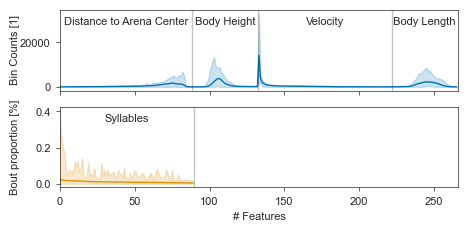

In [7]:
raw_scalars_df = approach_scalars_df.loc["raw"]
raw_moseq_df = approach_moseq_df.loc["raw"]

bin_dict = {
    "dist_to_center": np.linspace(0, 1, 90),
    "height": np.linspace(0, 60, 45),
    "velocity": np.linspace(0, 20, 90),
    "length": np.linspace(20, 100, 45)
}

figsize_cm=(12, 6)
figsize = [x/2.54 for x in figsize_cm]

hist_names = bin_dict.keys()
hist_widths = np.array([len(v)-1 for v in bin_dict.values()])
hist_borders = np.hstack([[0], hist_widths.cumsum()-0.5])
label_positions = hist_widths/2 + hist_borders[:-1]

fig, axs = plt.subplots(nrows=2, figsize=figsize, sharex=True)
axs = axs.flatten()

_plot_df = raw_scalars_df.rename_axis("x", axis=1).stack().rename("y").reset_index()
_plot_df["segmenter"] = "Scalars"
ax = sns.lineplot(_plot_df, x="x", y="y", errorbar="pi", ax=axs[0], hue="segmenter", palette=segmenter_cmap_dict, legend=False)
for x in hist_borders[1:-1]:
    ax.axvline(x, c="k", alpha=0.25)
y_max = ax.get_ylim()[1]

hist_label_rename_dict = {
    "dist_to_center": "Distance to Arena Center",
    "height": "Body Height",
    "velocity": "Velocity",
    "length": "Body Length",
}
for n, x in zip(hist_names, label_positions):
    ax.text(x, y_max*0.8, hist_label_rename_dict[n], ha="center")
ax.set_ylabel("Bin Counts [1]", labelpad=0)

_plot_df = raw_moseq_df.rename_axis("x", axis=1).stack().rename("y").reset_index()
_plot_df["segmenter"] = "MoSeq"
ax = sns.lineplot(_plot_df, x="x", y="y", errorbar="pi", ax=axs[1], hue="segmenter", palette=segmenter_cmap_dict, legend=False)
ax.axvline(len(raw_moseq_df.columns)-0.5, c="k", alpha=0.25)
y_max = ax.get_ylim()[1]
ax.text(len(raw_moseq_df.columns)/2, y_max*0.8, "Syllables", ha="center")

ax.set_xlim(0, len(raw_scalars_df.columns))
ax.set_xlabel("# Features")
ax.set_ylabel("Bout proportion [%]", labelpad=11)

fig.subplots_adjust(hspace=0)
fig.set_size_inches(figsize)
fig.tight_layout()
fig.savefig(plot_output_dir / "Fig1PanelA.svg", dpi=default_dpi)

## Panel B

In [8]:
approach_scalars_cosine_distances_plot_df = load_object(data_output_dir / "approach_scalars_cosine_distances_plot_df.pkl")
approach_moseq_cosine_distances_plot_df = load_object(data_output_dir / "approach_moseq_cosine_distances_plot_df.pkl")

plot_df = pd.concat({"Scalars": approach_scalars_cosine_distances_plot_df.loc["raw"].groupby(["drug_class1", "drug1", "dose1", "mouse_names1", "within_or_between"], sort=False).mean(),
                     "MoSeq": approach_moseq_cosine_distances_plot_df.loc["raw"].groupby(["drug_class1", "drug1", "dose1", "mouse_names1", "within_or_between"], sort=False).mean()}, names=["model"])

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\163679129.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fg.axes.flatten()[-1].set_xticklabels([_drug_to_abbr(x.get_text()) for x in fg.axes.flatten()[-1].get_xticklabels()])


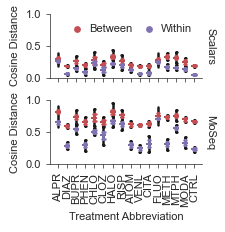

In [9]:
figsize_cm=(6, 6)
figsize = [x/2.54 for x in figsize_cm]

fg = sns.FacetGrid(plot_df.reset_index(), row="model", row_order=["Scalars", "MoSeq"], margin_titles=True, height=2, aspect=1.7)

fg.map_dataframe(sns.pointplot, x="drug1", y="cosine_distance", hue="within_or_between", palette=["k", "k"], dodge=False, errorbar="sd", ls="none", capsize=0.1, markers="_", zorder=0)
fg.map_dataframe(sns.pointplot, x="drug1", y="cosine_distance", hue="within_or_between", palette=["r", "m"], dodge=False, errorbar="ci", ls="none", capsize=0.25, markers="_", zorder=1)
fg.set(ylim=[0, 1], xlabel="")
fg.axes.flatten()[-1].tick_params("x", rotation=90)
fg.axes.flatten()[-1].set_xticklabels([_drug_to_abbr(x.get_text()) for x in fg.axes.flatten()[-1].get_xticklabels()])
fg.set_titles(row_template="{row_name}")
fg.set_ylabels("Cosine Distance")
fg.set_xlabels("Treatment Abbreviation")

first_ax = fg.axes.flatten()[0]
first_ax.scatter([], [], color="r", label="Between", s=15)
first_ax.scatter([], [], color="m", label="Within", s=15)
h, l = first_ax.get_legend_handles_labels()
first_ax.legend(handles=h[-2:], labels=l[-2:], frameon=False, ncols=2, columnspacing=0.5, handletextpad=0.1)

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.savefig(plot_output_dir / "Fig1PanelB.svg", dpi=default_dpi)

## Panel C

In [10]:
plot_df2 = plot_df.copy()["cosine_distance"].unstack("within_or_between")
plot_df2["wiltschko_ratio"] = plot_df2["between"] / (1 + plot_df2["within"])
plot_df2["corrected_wiltschko_ratio"] = plot_df2["within"] / (1 + plot_df2["between"])
plot_df2["ratio"] = plot_df2["within"] / plot_df2["between"]
plot_df2 = plot_df2.rename_axis("parameter", axis=1).stack().rename("cosine_distance_or_ratio")

plot_df2_edited = plot_df2.unstack()
_median = plot_df2_edited.groupby("model")["between"].median()
plot_df2_edited = plot_df2_edited[["within", "between"]].join(_median.rename("between_median"))
plot_df2_edited["within"] = plot_df2_edited["within"] / plot_df2_edited["between_median"]
plot_df2_edited["between"] = plot_df2_edited["between"] / plot_df2_edited["between_median"]
plot_df2_edited = plot_df2_edited[["within", "between"]]

plot_df2

model    drug_class1  drug1       dose1  mouse_names1                       parameter                
Scalars  benzo        alprazolam  Low    C57-10_.1mgkg_alprazolam_11-22-16  between                      0.181536
                                                                            within                       0.203779
                                                                            wiltschko_ratio              0.150805
                                                                            corrected_wiltschko_ratio    0.172470
                                                                            ratio                        1.122524
                                                                                                           ...   
MoSeq    control      control     Low    C57-10_saline_ofa60min_110316      between                      0.712201
                                                                            within                  

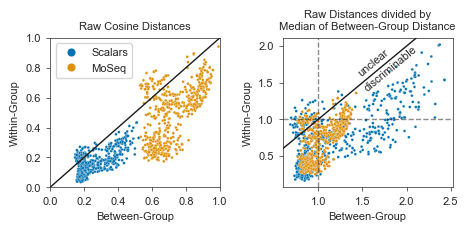

In [11]:
figsize_cm=(12, 6)
figsize = [x/2.54 for x in figsize_cm]

fig, axs = plt.subplots(1, 2, figsize=figsize)
axs = axs.flatten()

ax = sns.scatterplot(plot_df2.unstack("parameter").reset_index(), x="between", y="within", hue="model", palette=segmenter_cmap_dict, legend=True, ax=axs[0])
add_xy_line(ax, xy_factor=1, c="k")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='best', markerscale=3)
ax.set_title("Raw Cosine Distances")
ax.set_xlabel("Between-Group")
ax.set_ylabel("Within-Group")

ax = sns.scatterplot(plot_df2_edited.reset_index(), x="between", y="within", hue="model", palette=segmenter_cmap_dict, legend=False, ax=axs[1])
add_xy_line(ax, xy_factor=1, c="k")
add_xy_annotation(ax, "unclear", xy_factor=1, va="bottom", ha="left", relative_position=0.6, y_shift=0.05)
add_xy_annotation(ax, "discriminable", xy_factor=1, va="top", ha="left", relative_position=0.6, y_shift=-0.05)
ax.axvline(1, ls="--", alpha=0.5, c="k")
ax.axhline(1, ls="--", alpha=0.5, c="k")
ax.set_title("Raw Distances divided by\nMedian of Between-Group Distance")
ax.set_xlabel("Between-Group")
ax.set_ylabel("Within-Group")

fig.set_size_inches(figsize)
fig.tight_layout()
fig.savefig(plot_output_dir / "Fig1PanelC.svg", dpi=default_dpi)

## Panel D

In [12]:
ratio_plot_df = plot_df2.unstack("parameter")
ratio_plot_df = ratio_plot_df.loc["MoSeq"] / ratio_plot_df.loc["Scalars"]
ratio_plot_df

parameter                                                        between  \
drug_class1 drug1      dose1 mouse_names1                                  
benzo       alprazolam Low   C57-10_.1mgkg_alprazolam_11-22-16  3.689663   
                             C57-11_.1mgkg_alprazolam_11-22-16  3.980001   
                             C57-12_.1mgkg_alprazolam_11-22-16  3.469412   
                             C57-1_.1mgkg_alprazolam_11-22-16   3.745650   
                             C57-2_.1mgkg_alprazolam_11-22-16   3.633068   
...                                                                  ...   
control     control    Low   C57-6_saline_ofa60min_110216       3.549651   
                             C57-7_saline_ofa60min_110216       3.600124   
                             C57-8_saline_ofa60min_110216       3.108545   
                             C57-9_saline_ofa60min_110216       3.393758   
                             C57-10_saline_ofa60min_110316      3.744661   

parameter                                                         within  \
drug_class1 drug1      dose1 mouse_names1                                  
benzo       alprazolam Low   C57-10_.1mgkg_alprazolam_11-22-16  3.214847   
                             C57-11_.1mgkg_alprazolam_11-22-16  2.650844   
                             C57-12_.1mgkg_alprazolam_11-22-16  2.579608   
                             C57-1_.1mgkg_alprazolam_11-22-16   2.297174   
                             C57-2_.1mgkg_alprazolam_11-22-16   2.445839   
...                                                                  ...   
control     control    Low   C57-6_saline_ofa60min_110216       4.168781   
                             C57-7_saline_ofa60min_110216       6.209882   
                             C57-8_saline_ofa60min_110216       4.467275   
                             C57-9_saline_ofa60min_110216       4.995333   
                             C57-10_saline_ofa60min_110316      6.587755   

parameter                                                       wiltschko_ratio  \
drug_class1 drug1      dose1 mouse_names1                                         
benzo       alprazolam Low   C57-10_.1mgkg_alprazolam_11-22-16         2.683517   
                             C57-11_.1mgkg_alprazolam_11-22-16         3.071163   
                             C57-12_.1mgkg_alprazolam_11-22-16         2.673854   
                             C57-1_.1mgkg_alprazolam_11-22-16          2.942789   
                             C57-2_.1mgkg_alprazolam_11-22-16          2.826274   
...                                                                         ...   
control     control    Low   C57-6_saline_ofa60min_110216              3.079612   
                             C57-7_saline_ofa60min_110216              3.057194   
                             C57-8_saline_ofa60min_110216              2.584097   
                             C57-9_saline_ofa60min_110216              2.828872   
                             C57-10_saline_ofa60min_110316             3.025506   

parameter                                                       corrected_wiltschko_ratio  \
drug_class1 drug1      dose1 mouse_names1                                                   
benzo       alprazolam Low   C57-10_.1mgkg_alprazolam_11-22-16                   2.274787   
                             C57-11_.1mgkg_alprazolam_11-22-16                   1.829724   
                             C57-12_.1mgkg_alprazolam_11-22-16                   1.862006   
                             C57-1_.1mgkg_alprazolam_11-22-16                    1.526361   
                             C57-2_.1mgkg_alprazolam_11-22-16                    1.639865   
...                                                                                   ...   
control     control    Low   C57-6_saline_ofa60min_110216                        2.967466   
                             C57-7_saline_ofa60min_110216                        4.435027   
            

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\2763938351.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_replacements.get(l.get_text(), l) for l in ax.get_xticklabels()])


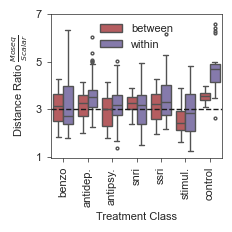

In [13]:
figsize_cm=(6, 6)
figsize = [x/2.54 for x in figsize_cm]

label_replacements = dict(antidepressant="antidep.", antipsychotic="antipsy.", stimulant="stimul.")

fig, ax = plt.subplots(figsize=figsize)

ratio_plot_df = plot_df2.unstack("parameter")
ratio_plot_df = ratio_plot_df.loc["MoSeq"] / ratio_plot_df.loc["Scalars"]
ratio_plot_df = ratio_plot_df[["between", "within"]].rename_axis("distance_measure", axis=1).stack().rename("distance_ratio").reset_index()

ax = sns.boxplot(ratio_plot_df, x="drug_class1", y="distance_ratio", hue="distance_measure", palette=["r", "m"], ax=ax)
ax.axhline(3, ls="--", c="k")
ax.legend(frameon=False)
ax.tick_params("x", rotation=90)
ax.set_yticks([1, 3, 5, 7])
ax.set_xlabel("")
ax.set_ylabel(r"Distance Ratio $\frac{Moseq}{Scalar}$")
ax.set_xticklabels([label_replacements.get(l.get_text(), l) for l in ax.get_xticklabels()])
ax.set_xlabel("Treatment Class")

fig.set_size_inches(figsize)
fig.tight_layout()
fig.savefig(plot_output_dir / "Fig1PanelD.svg", dpi=default_dpi)

## Panel E

In [14]:
stat_df = apply_statistical_test_to_series(plot_df2, comparison_levels=["model"], group_levels=["parameter"], parametric_test=True, pair_levels=["drug_class1", "drug1", "dose1", "mouse_names1"], alternative="two-sided")
stat_df["significant"] = stat_df["pvalue"].lt(0.05 / len(stat_df))
stat_df

,,,statistic,pvalue,significant
parameter,comparison1,comparison2,,,
between,MoSeq,Scalars,174.880942,0.000000e+00,True
corrected_wiltschko_ratio,MoSeq,Scalars,56.075848,8.262913e-218,True
ratio,MoSeq,Scalars,4.487040,8.970165e-06,True
wiltschko_ratio,MoSeq,Scalars,103.086504,0.000000e+00,True
within,MoSeq,Scalars,59.078760,1.181147e-227,True


C:\Users\marti\AppData\Local\Temp\ipykernel_61228\854418543.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_replacements.get(l.get_text(), l) for l in ax.get_xticklabels()])


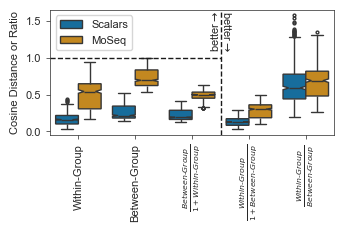

In [15]:
figsize_cm=(9, 6)
figsize = [x/2.54 for x in figsize_cm]

label_replacements = dict(within="Within-Group", between="Between-Group", 
                          wiltschko_ratio=r"$\frac{Between\text{-}Group}{1 + Within\text{-}Group}$", 
                          corrected_wiltschko_ratio=r"$\frac{Within\text{-}Group}{1 + Between\text{-}Group}$",
                          ratio=r"$\frac{Within\text{-}Group}{Between\text{-}Group}$"
                          )

hue_order = ["Scalars", "MoSeq"]
pal = sns.palettes.color_palette("colorblind")
pal.reverse()
palette = dict(zip(hue_order, (pal[1], pal[0])))

fig, ax = plt.subplots(figsize=figsize)
ax = sns.boxplot(plot_df2.reset_index(), x="parameter", order=["within", "between", "wiltschko_ratio", "corrected_wiltschko_ratio", "ratio"], y="cosine_distance_or_ratio", 
                 hue="model", hue_order=["Scalars", "MoSeq"], palette=segmenter_cmap_dict, notch=True)
ax.set_xlabel("")
ax.set_xticklabels([label_replacements.get(l.get_text(), l) for l in ax.get_xticklabels()])
ax.set_ylabel("Cosine Distance or Ratio")
ax.tick_params("x", rotation=90)
ax.legend(title="")

ax.axvline(2.5, ls="--", c="k")

ax.hlines(1, xmin=-0.5, xmax=2.5, color="k", ls="--")
ax.set_xlim(-0.5, 4.5)
ax.text(2.5, 1.1, s=r"better$\rightarrow$", rotation=90, ha="right")
ax.text(2.5, 1.1, s=r"better$\rightarrow$", rotation=-90, ha="left")

fig.set_size_inches(figsize)
fig.tight_layout()
fig.savefig(plot_output_dir / "Fig1PanelE.svg", dpi=default_dpi)

## Panel F

In [16]:
shapiro_stat_df = plot_df2.groupby(["model", "parameter"]).apply(lambda x: dict(zip(["statistic", "p-value"], shapiro(x)))).unstack()
significance_threshold = 0.05/len(shapiro_stat_df)
shapiro_stat_df["significant"] = shapiro_stat_df["p-value"].lt(significance_threshold)
shapiro_stat_df

statistic       p-value  significant
model   parameter                                                      
MoSeq   between                     0.932732  3.117103e-14         True
        corrected_wiltschko_ratio   0.952586  1.348463e-11         True
        ratio                       0.968416  6.519603e-09         True
        wiltschko_ratio             0.962172  4.702384e-10         True
        within                      0.943247  6.494212e-13         True
Scalars between                     0.860712  1.092474e-20         True
        corrected_wiltschko_ratio   0.976474  3.221512e-07         True
        ratio                       0.941846  4.242368e-13         True
        wiltschko_ratio             0.887324  1.133203e-18         True
        within                      0.967854  5.082939e-09         True

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\2965025643.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_replacements.get(l.get_text(), l) for l in ax.get_xticklabels()])


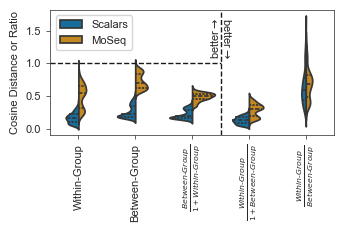

In [17]:
figsize_cm=(9, 6)
figsize = [x/2.54 for x in figsize_cm]

hue_order = ["scalars", "moseq"]
pal = sns.palettes.color_palette("colorblind")
pal.reverse()
palette = dict(zip(hue_order, (pal[1], pal[0])))

fig, ax = plt.subplots(figsize=figsize)
ax = sns.violinplot(plot_df2.reset_index(), x="parameter", order=["within", "between", "wiltschko_ratio", "corrected_wiltschko_ratio", "ratio"], y="cosine_distance_or_ratio", 
                 hue="model", hue_order=["Scalars", "MoSeq"], palette=segmenter_cmap_dict, split=True, inner="quart")
ax.set_xlabel("")
ax.set_xticklabels([label_replacements.get(l.get_text(), l) for l in ax.get_xticklabels()])
ax.set_ylabel("Cosine Distance or Ratio")
ax.tick_params("x", rotation=90)
ax.legend(title="")

ax.axvline(2.5, ls="--", c="k")

ax.hlines(1, xmin=-0.5, xmax=2.5, color="k", ls="--")
ax.set_xlim(-0.5, 4.5)
ax.text(2.5, 1.1, s=r"better$\rightarrow$", rotation=90, ha="right")
ax.text(2.5, 1.1, s=r"better$\rightarrow$", rotation=-90, ha="left")

fig.set_size_inches(figsize)
fig.tight_layout()
fig.savefig(plot_output_dir / "Fig1PanelF.svg", dpi=default_dpi)
# why t-test? did they test normality?

# Figure 2

18 x 11cm

First row

    Panel a: 11 x 11
    Panel b: 7 x 11

## Panel A

In [18]:
classifier_rename_dict = dict(
    NC_Manhattan="Nearest Centroid", 
    DecisionTree="Decision Tree", 
    KNeighbors="K-Nearest Neighbors", 
    LDA="Linear Discriminant Analysis", 
    LogReg_Optimized="Logistic Regression",
    NaiveBayes="Naive Bayes",
    Perceptron="Perceptron",
    RandomForest="Random Forest",
    Ridge="Ridge",
    SVC="Support Vector"
    )

cross_val_prediction_dict = load_object(data_output_dir / "cross_val_prediction_dict.pkl")
cross_val_prediction_series = pd.concat(cross_val_prediction_dict, names=["approach", "classifier", "cross_validation"])
_idx = cross_val_prediction_series.index.to_frame()
_idx["segmenter"] = _idx["segmenter"].apply(dict(scalars="Scalars", moseq="MoSeq").get)
_idx["classifier"] = _idx["classifier"].apply(classifier_rename_dict.get)
cross_val_prediction_series.index = pd.MultiIndex.from_frame(_idx)
cross_val_prediction_series

approach  classifier           cross_validation  segmenter  phase     treatment  uniform_dosage_term  treatment_mouse_id
density   K-Nearest Neighbors  LOO               MoSeq      Solitary  bupropion  high                 10                    (methylphenidate, low)
                                                                                                      11                    (methylphenidate, low)
                                                                                                      12                    (methylphenidate, low)
                                                                                                      1                          (bupropion, high)
                                                                                                      2                          (bupropion, high)
                                                                                                                                     ...        

In [19]:
def vector_df_to_expected_label_series(vector_df_or_predicted_label_series):
    X = vector_df_or_predicted_label_series.copy()
    y = X.index.to_frame()[["treatment", "uniform_dosage_term"]].apply(tuple, axis=1)
    return y

def predicted_label_series_to_label_proportion_df(predicted_label_series):
    predicted_label_counts_df = predicted_label_series.apply(lambda x: x[0]).groupby(
        ["segmenter", "phase", "treatment"]).value_counts().unstack()
    return (predicted_label_counts_df.T / predicted_label_counts_df.sum(axis=1)).T.fillna(0)

drug_order = [s.strip() for s in open(data_output_dir / "drug_order.txt", mode="r").readlines()]
_drug_order2 = [(s if s!="VEH" else "control") for s in drug_order]

drug_class_df = approach_scalars_df.loc["raw"].index.to_frame(index=False)[["drug_class", "drug"]].value_counts().index.to_frame(index=False)
drug_class_df = drug_class_df.sort_values(by="drug", key=lambda x: [_drug_order2.index(l) for l in x])
drug_class_width = drug_class_df.groupby("drug_class", sort=False).size()
drug_class_positions = drug_class_width.cumsum()
drug_class_positions

drug_class
benzo              2
antidepressant     4
antipsychotic      8
snri              10
ssri              12
stimulant         15
control           16
dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\3080089452.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  nc_predicted_label_series = cross_val_prediction_series.loc["raw", "Nearest Centroid", "LOO"]
C:\Users\marti\AppData\Local\Temp\ipykernel_61228\3080089452.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  lr_predicted_label_series = cross_val_prediction_series.loc["raw", "Logistic Regression", "LOO"]


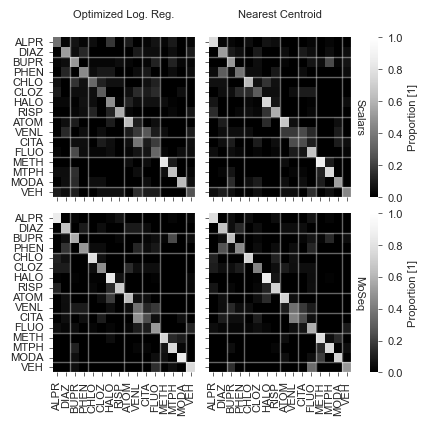

In [20]:
nc_predicted_label_series = cross_val_prediction_series.loc["raw", "Nearest Centroid", "LOO"]
lr_predicted_label_series = cross_val_prediction_series.loc["raw", "Logistic Regression", "LOO"]

plot_df = pd.concat({
    "Nearest Centroid\n": predicted_label_series_to_label_proportion_df(nc_predicted_label_series).loc[pd.IndexSlice[:, :, drug_order], drug_order],
    "Optimized Log. Reg.\n": predicted_label_series_to_label_proportion_df(lr_predicted_label_series).loc[pd.IndexSlice[:, :, drug_order], drug_order],
}, names=["classifier"])

_idx = plot_df.index.to_frame()
_idx["treatment"] = _idx["treatment"].apply(_drug_to_abbr)
plot_df.index = pd.MultiIndex.from_frame(_idx)
plot_df.columns = [_drug_to_abbr(col) for col in plot_df.columns]

figsize_cm=(11, 11)
figsize = [x/2.54 for x in figsize_cm]

fg = sns.FacetGrid(plot_df.reset_index(), row="segmenter", row_order=["Scalars", "MoSeq"], col="classifier", col_order=["Optimized Log. Reg.\n", "Nearest Centroid\n"], height=4, aspect=1, margin_titles=True)

def _plot(data, add_lines=True, *args, **kwargs):
    ax = plt.gca()
    data = data.drop(["classifier", "segmenter", "phase"], axis=1).set_index("treatment")
    ax = sns.heatmap(data, cmap="Greys_r", vmin=0, vmax=1, ax=ax, cbar=True, cbar_kws=dict(pad=0.1, label="Proportion [1]"))
    if add_lines:
        for p in drug_class_positions:
            ax.axhline(p, c="w", alpha=0.4)
            ax.axvline(p, c="w", alpha=0.4)

fg.map_dataframe(_plot, add_lines=True)
fg.set_titles(row_template="{row_name}", col_template="{col_name}")
fg.set(xlabel="", ylabel="")

fg.figure.axes[-4].remove()
fg.figure.axes[-2].remove()
fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.subplots_adjust(left=0.125, right=0.925, hspace=0.1, top=0.9)
fg.figure.savefig(plot_output_dir / "Fig2PanelA.svg", dpi=default_dpi)

## Panel B

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\2869001767.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  plot_df1 = predicted_label_series_to_label_proportion_df(cross_val_prediction_series.loc["raw", "Nearest Centroid", "LOO"].loc[["Scalars", "MoSeq"]]).loc[pd.IndexSlice[:, :, drug_order], drug_order]
C:\Users\marti\AppData\Local\Temp\ipykernel_61228\2869001767.py:33: PerformanceWarning: indexing past lexsort depth may impact performance.
  plot_df2 = predicted_label_series_to_label_proportion_df(cross_val_prediction_series.loc["raw", "Logistic Regression", "LOO"].loc[["Scalars", "MoSeq"]]).loc[pd.IndexSlice[:, :, drug_order], drug_order]


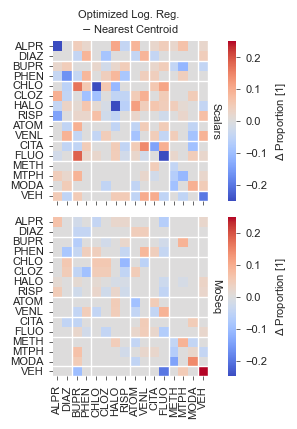

In [21]:
def plot_delta_confusion_matrices(plot_df, add_lines=True):
    plot_df = plot_df.loc[pd.IndexSlice[:, :, drug_order], drug_order]
    plot_df = pd.concat({
        "Optimized Log. Reg. \n$-$ Nearest Centroid": plot_df
    }, names=["classifier"])

    _idx = plot_df.index.to_frame()
    _idx["treatment"] = _idx["treatment"].apply(_drug_to_abbr)
    plot_df.index = pd.MultiIndex.from_frame(_idx)
    plot_df.columns = [_drug_to_abbr(col) for col in plot_df.columns]

    fg = sns.FacetGrid(plot_df.reset_index(), row="segmenter", row_order=["Scalars", "MoSeq"], col="classifier", col_order=["Optimized Log. Reg. \n$-$ Nearest Centroid"], height=4, aspect=1, margin_titles=True)

    def _plot(data, add_lines=True, *args, **kwargs):
        ax = plt.gca()
        data = data.drop(["classifier", "segmenter", "phase"], axis=1).set_index("treatment")
        ax = sns.heatmap(data, cmap="coolwarm", vmin=-0.25, vmax=0.25, ax=ax, cbar=True, cbar_kws=dict(pad=0.1, label=r"$\Delta$ Proportion [1]"))
        if add_lines:
            for p in drug_class_positions:
                ax.axhline(p, c="w")
                ax.axvline(p, c="w")

    fg.map_dataframe(_plot, add_lines=add_lines)
    fg.set_titles(row_template="{row_name}", col_template="{col_name}")
    fg.set(xlabel="", ylabel="")

    return fg

figsize_cm=(7, 11)
figsize = [x/2.54 for x in figsize_cm]

plot_df1 = predicted_label_series_to_label_proportion_df(cross_val_prediction_series.loc["raw", "Nearest Centroid", "LOO"].loc[["Scalars", "MoSeq"]]).loc[pd.IndexSlice[:, :, drug_order], drug_order]
plot_df2 = predicted_label_series_to_label_proportion_df(cross_val_prediction_series.loc["raw", "Logistic Regression", "LOO"].loc[["Scalars", "MoSeq"]]).loc[pd.IndexSlice[:, :, drug_order], drug_order]
fg = plot_delta_confusion_matrices(plot_df2 - plot_df1)

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.subplots_adjust(left=0.15, right=0.9, hspace=0.1, top=0.9)
fg.figure.savefig(plot_output_dir / "Fig2PanelB.svg", dpi=default_dpi)

# Figure 3

18 x 9cm

In [22]:
cross_val_prediction_series2 = cross_val_prediction_series.loc["raw"]
cross_val_prediction_series2

classifier           cross_validation  segmenter  phase     treatment  uniform_dosage_term  treatment_mouse_id
Nearest Centroid     LOO               MoSeq      Solitary  bupropion  high                 10                      (bupropion, high)
                                                                                            11                      (bupropion, high)
                                                                                            12                      (bupropion, high)
                                                                                            1                       (bupropion, high)
                                                                                            2                       (bupropion, high)
                                                                                                                         ...         
Logistic Regression  LOO               Scalars    Solitary  modafinil  low           

In [23]:
expected_drug_label_series = vector_df_to_expected_label_series(cross_val_prediction_series2).apply(lambda x: x[0]).sort_index()
predicted_drug_label_series = cross_val_prediction_series2.apply(lambda x: x[0]).sort_index()
recall_binom_df = predicted_drug_label_series.groupby(["classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: get_recall_binom_test_series(x.values, expected_drug_label_series.loc[x.name].values, chance_level=1/len(drug_order))).unstack()
treatment_recall_series = predicted_drug_label_series.eq(expected_drug_label_series).groupby(["classifier", "cross_validation", "segmenter", "phase", "treatment"]).value_counts(normalize=True).unstack().fillna(0)[True]

f1_series = predicted_drug_label_series.groupby(["classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: f1_score(x, expected_drug_label_series.loc[x.name], average="weighted")).rename("f1_weighted")
recall_series = predicted_drug_label_series.groupby(["classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: x.eq(expected_drug_label_series.loc[x.name]).value_counts(normalize=True)[True]).rename("global_recall")
f1_series

classifier                    cross_validation  segmenter  phase   
Decision Tree                 LOO               MoSeq      Solitary    0.522197
                                                Scalars    Solitary    0.460091
K-Nearest Neighbors           LOO               MoSeq      Solitary    0.618038
                                                Scalars    Solitary    0.486154
Linear Discriminant Analysis  LOO               MoSeq      Solitary    0.686480
                                                Scalars    Solitary    0.414187
Logistic Regression           LOO               MoSeq      Solitary    0.663977
                                                Scalars    Solitary    0.446835
Naive Bayes                   LOO               MoSeq      Solitary    0.647023
                                                Scalars    Solitary    0.524630
Nearest Centroid              LOO               MoSeq      Solitary    0.657451
                                                Scal

In [24]:
classifier_order = list((recall_binom_df.xs("MoSeq", level="segmenter") - recall_binom_df.xs("Scalars", level="segmenter"))["recall"].sort_values().index.get_level_values("classifier"))
plot_df = recall_binom_df.loc[pd.IndexSlice[:, :, ["Scalars", "MoSeq"]]].reset_index()
plot_df2 = treatment_recall_series.loc[pd.IndexSlice[:, :, ["Scalars", "MoSeq"]]].rename("recall").sort_index().reset_index("segmenter")

plot_df["x"] = plot_df.apply(lambda x: segmenter_order2.index(x["segmenter"]), axis=1)
plot_df[["ci_down", "ci_up"]] = (plot_df[["low", "high"]].T - plot_df["recall"]).T.abs()

plot_df2["x"] = plot_df2.apply(lambda x: segmenter_order2.index(x["segmenter"]), axis=1)

significance_df = apply_statistical_test_to_series(treatment_recall_series.loc[pd.IndexSlice[:, :, ["Scalars", "MoSeq"]]].droplevel("phase"), comparison_levels=["segmenter"], group_levels=["classifier", "cross_validation"], pair_levels=["treatment"], parametric_test=False)
significance_threshold = 0.05 / (significance_df.index.get_level_values("classifier").nunique())
significance_df["phase_significance"] = significance_df["pvalue"].lt(significance_threshold)
significance_df = significance_df.join(plot_df.groupby(["classifier", "cross_validation"])[["x", "recall"]].mean())
significance_df

,,,,statistic,pvalue,phase_significance,x,recall
classifier,cross_validation,comparison1,comparison2,,,,,
Decision Tree,LOO,MoSeq,Scalars,15.0,0.033047,False,0.5,0.488024
K-Nearest Neighbors,LOO,MoSeq,Scalars,8.0,0.003143,True,0.5,0.550898
Linear Discriminant Analysis,LOO,MoSeq,Scalars,3.0,0.001206,True,0.5,0.550898
Logistic Regression,LOO,MoSeq,Scalars,3.0,0.001206,True,0.5,0.558882
Naive Bayes,LOO,MoSeq,Scalars,10.0,0.004514,True,0.5,0.584830
Nearest Centroid,LOO,MoSeq,Scalars,10.0,0.007630,False,0.5,0.621756
Perceptron,LOO,MoSeq,Scalars,21.0,0.026757,False,0.5,0.351297
Random Forest,LOO,MoSeq,Scalars,7.5,0.007896,False,0.5,0.653693
Ridge,LOO,MoSeq,Scalars,22.0,0.100525,False,0.5,0.406188


In [25]:
recall_binom_df.groupby("classifier")["recall"].mean().sort_values(ascending=False)

classifier
Random Forest                   0.653693
Nearest Centroid                0.621756
Support Vector                  0.604790
Naive Bayes                     0.584830
Logistic Regression             0.558882
K-Nearest Neighbors             0.550898
Linear Discriminant Analysis    0.550898
Decision Tree                   0.488024
Ridge                           0.406188
Perceptron                      0.351297
Name: recall, dtype: float64

e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\matplotlib\cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\matplotlib\cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\matplotlib\cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\matplotlib\cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.is

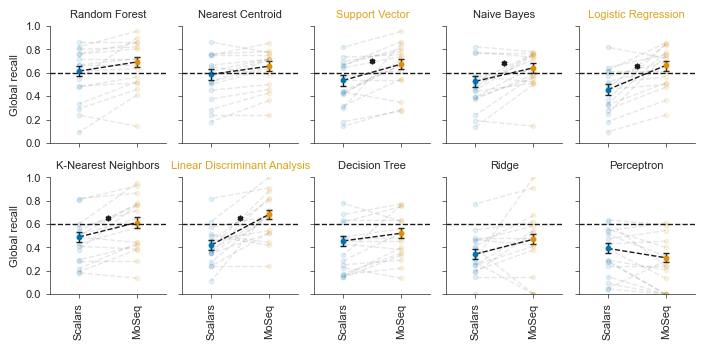

In [26]:
selected_classifiers = ["Logistic Regression", "Support Vector", "Linear Discriminant Analysis"]
figsize_cm=(18, 9)
figsize = [x/2.54 for x in figsize_cm]

fg = sns.FacetGrid(plot_df.reset_index(), col="classifier", col_order=recall_binom_df.groupby("classifier")["recall"].mean().sort_values(ascending=False).index, col_wrap=5, margin_titles=True, height=1.5, aspect=0.75)

def _plot(data, *args, **kwargs):
    ax = plt.gca()

    old_data = data.copy()

    for segmenter, segmenter_data in data.groupby("segmenter"):
        data = segmenter_data
        classifier = data["classifier"].unique()[0]
        cross_validation = data["cross_validation"].unique()[0]

        data2 = plot_df2.loc[classifier, cross_validation].reset_index().set_index("segmenter").loc[segmenter]

        ax.scatter(data["x"], data["recall"], s=10, color=segmenter_cmap_dict[segmenter])
        ax.errorbar(data["x"], data["recall"], yerr=(data["ci_down"], data["ci_up"]), ls="none", capsize=2, color=segmenter_cmap_dict[segmenter], ecolor="k", zorder=-100)
        ax.plot(data["x"], data["recall"], color=segmenter_cmap_dict[segmenter], zorder=100)

        ax.scatter(data2["x"], data2["recall"], s=10, color=segmenter_cmap_dict[segmenter], alpha=0.1)

        _plot_significance_df = significance_df.loc[classifier, cross_validation]
        _plot_significance_df = _plot_significance_df[_plot_significance_df["phase_significance"]]
        x, y = _plot_significance_df["x"], _plot_significance_df["recall"]
        ax.scatter(x=x, y=y+0.1, marker="$*$", s=10, c="k")

    ax.plot(old_data["x"], old_data["recall"], ls="--", c="k", zorder=0)
    data2 = plot_df2.loc[classifier, cross_validation]
    for treatment, treatment_plot_df in data2.groupby("treatment"):
        ax.plot(treatment_plot_df["x"], treatment_plot_df["recall"], c="k", zorder=-1, alpha=0.1, ls="--")

fg.map_dataframe(_plot)
fg.tick_params("x", rotation=90)
fg.set_titles(row_template="{row_name}", col_template="{col_name}")
fg.add_legend()
fg.set(ylim=[0,1], xlim=[-0.5, 1.5], xticks=[0, 1])
fg.refline(y=0.6, ls="--", c="k")
fg.set_ylabels("Global recall")
fg.set_xticklabels(labels=segmenter_order2)

for ax in fg.axes.flatten():
    title_text = ax.get_title()
    if title_text in selected_classifiers:
        ax.set_title(title_text, c="goldenrod")

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.savefig(plot_output_dir / "Fig3.svg", dpi=default_dpi)

# Figure 4

18 x 17cm

First row

    Panel a: 8 x 4
    Panel b: 4 x 4
    Panel c: 6 x 4

Second row

    Panel d: 8 x 4
    Panel e: 4 x 4
    Panel f: 6 x 4

Third row

    Panel g: 4 x 9
    Panel h: 14 x 9

## Panel A

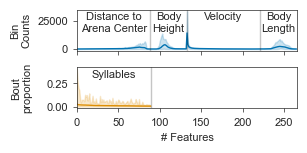

In [27]:
bin_dict = {
    "dist_to_center": np.linspace(0, 1, 90),
    "height": np.linspace(0, 60, 45),
    "velocity": np.linspace(0, 20, 90),
    "length": np.linspace(20, 100, 45)
}

figsize_cm=(8, 4)
figsize = [x/2.54 for x in figsize_cm]

hist_names = bin_dict.keys()
hist_widths = np.array([len(v)-1 for v in bin_dict.values()])
hist_borders = np.hstack([[0], hist_widths.cumsum()-0.5])
label_positions = hist_widths/2 + hist_borders[:-1]

fig, axs = plt.subplots(nrows=2, figsize=figsize, sharex=True)
axs = axs.flatten()

_plot_df = raw_scalars_df.rename_axis("x", axis=1).stack().rename("y").reset_index()
_plot_df["segmenter"] = "Scalars"
ax = sns.lineplot(_plot_df, x="x", y="y", errorbar="pi", ax=axs[0], hue="segmenter", palette=segmenter_cmap_dict, legend=False)
for x in hist_borders[1:-1]:
    ax.axvline(x, c="k", alpha=0.25)
y_max = ax.get_ylim()[1]

hist_label_rename_dict = {
    "dist_to_center": "Distance to\nArena Center",
    "height": "Body\nHeight",
    "velocity": "Velocity\n",
    "length": "Body\nLength",
}
for n, x in zip(hist_names, label_positions):
    ax.text(x, y_max*0.45, hist_label_rename_dict[n], ha="center")
ax.set_ylabel("Bin\nCounts", labelpad=4)

_plot_df = raw_moseq_df.rename_axis("x", axis=1).stack().rename("y").reset_index()
_plot_df["segmenter"] = "MoSeq"
ax = sns.lineplot(_plot_df, x="x", y="y", errorbar="pi", ax=axs[1], hue="segmenter", palette=segmenter_cmap_dict, legend=False)
ax.axvline(len(raw_moseq_df.columns)-0.5, c="k", alpha=0.25)
y_max = ax.get_ylim()[1]
ax.text(len(raw_moseq_df.columns)/2, y_max*0.45, "Syllables\n", ha="center")

ax.set_xlim(0, len(raw_scalars_df.columns))
ax.set_xlabel("# Features")
ax.set_ylabel("Bout\nproportion", labelpad=10)

fig.subplots_adjust(hspace=0)
fig.set_size_inches(figsize)
fig.tight_layout()
fig.subplots_adjust(left=0.25, right=0.95)
fig.savefig(plot_output_dir / "Fig4PanelA.svg", dpi=default_dpi)

## Panel B

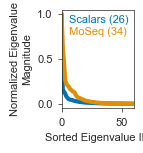

In [28]:
figsize_cm=(4, 4)
figsize = [x/2.54 for x in figsize_cm]

scalar_cov = raw_scalars_df.cov()
scalar_eig_val, _scalar_eig_vec = np.linalg.eig(scalar_cov)

moseq_cov = raw_moseq_df.cov()
moseq_eig_val, _moseq_eig_vec = np.linalg.eig(moseq_cov)

scalar_eig_val = scalar_eig_val / scalar_eig_val.max()
scalar_effective_dims = (scalar_eig_val >= 0.01).sum()
moseq_eig_val = moseq_eig_val / moseq_eig_val.max()
moseq_effective_dims = (moseq_eig_val >= 0.01).sum()

fig, ax = plt.subplots(figsize=figsize)
ax.plot(scalar_eig_val, lw=3, label=f"Scalars ({scalar_effective_dims})", c=segmenter_cmap_dict["Scalars"])
ax.plot(moseq_eig_val, lw=3, label=f"MoSeq ({moseq_effective_dims})", c=segmenter_cmap_dict["MoSeq"])
ax.set_xlim([0, 60])
handles, labels = ax.get_legend_handles_labels()
text_shift = 0.125
for i, (h, l) in enumerate(zip(handles, labels)):
    ax.text(0.1, 0.95-i*text_shift, l, c=h.get_color(), ha="left", va="top", transform=ax.transAxes)
ax.set_xlabel("Sorted Eigenvalue ID")
ax.set_ylabel("Normalized Eigenvalue\nMagnitude")
fig.tight_layout()
fig.subplots_adjust(right=0.9)
fig.savefig(plot_output_dir / "Fig4PanelB.svg", dpi=default_dpi)

## Panel C

In [29]:
approach_scalars_cosine_distances_df = load_object(data_output_dir / "approach_scalars_cosine_distances_plot_df.pkl")
approach_moseq_cosine_distances_df = load_object(data_output_dir / "approach_moseq_cosine_distances_plot_df.pkl")
plot_df = pd.concat({"Scalars": approach_scalars_cosine_distances_df.loc["raw"].groupby(["drug_class1", "drug1", "dose1", "mouse_names1", "within_or_between"], sort=False).mean(),
           "MoSeq": approach_moseq_cosine_distances_df.loc["raw"].groupby(["drug_class1", "drug1", "dose1", "mouse_names1", "within_or_between"], sort=False).mean()}, names=["model"])

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\320826936.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fg.axes.flatten()[-1].set_xticklabels([_drug_to_abbr(x.get_text()) for x in fg.axes.flatten()[-1].get_xticklabels()])


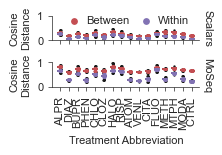

In [30]:
figsize_cm=(6, 4)
figsize = [x/2.54 for x in figsize_cm]

fg = sns.FacetGrid(plot_df.reset_index(), row="model", row_order=["Scalars", "MoSeq"], margin_titles=True, height=2, aspect=1.7)

fg.map_dataframe(sns.pointplot, x="drug1", y="cosine_distance", hue="within_or_between", palette=["k", "k"], dodge=False, errorbar="sd", ls="none", capsize=0.1, markers="_", zorder=0, legend=False)
fg.map_dataframe(sns.pointplot, x="drug1", y="cosine_distance", hue="within_or_between", palette=["r", "m"], dodge=False, errorbar="ci", ls="none", capsize=0.25, markers="_", zorder=1)
fg.set(ylim=[0, 1], xlabel="")
fg.axes.flatten()[-1].tick_params("x", rotation=90)
fg.axes.flatten()[-1].set_xticklabels([_drug_to_abbr(x.get_text()) for x in fg.axes.flatten()[-1].get_xticklabels()])
fg.set_titles(row_template="{row_name}")
fg.set_ylabels("Cosine\nDistance")
fg.set_xlabels("Treatment Abbreviation")

first_ax = fg.axes.flatten()[0]
first_ax.scatter([], [], color="r", label="Between", s=15)
first_ax.scatter([], [], color="m", label="Within", s=15)
h, l = first_ax.get_legend_handles_labels()
first_ax.legend(handles=h[-2:], labels=l[-2:], loc="center", bbox_to_anchor=(0.5, 0.8, 0, 0), frameon=False, ncols=2, columnspacing=0.5, handletextpad=0.1)

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.savefig(plot_output_dir / "Fig4PanelC.svg", dpi=default_dpi)

## Panel D

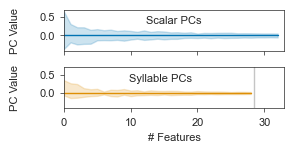

In [31]:
bin_dict = {
    "dist_to_center": np.linspace(0, 1, 90),
    "height": np.linspace(0, 60, 45),
    "velocity": np.linspace(0, 20, 90),
    "length": np.linspace(20, 100, 45)
}

pca_scalars_df = approach_scalars_df.loc["pca"].dropna(how="all", axis=1)
pca_moseq_df = approach_moseq_df.loc["pca"].dropna(how="all", axis=1)

figsize_cm=(8, 4)
figsize = [x/2.54 for x in figsize_cm]

hist_names = bin_dict.keys()
hist_widths = np.array([len(v)-1 for v in bin_dict.values()])
hist_borders = np.hstack([[0], hist_widths.cumsum()-0.5])
label_positions = hist_widths/2 + hist_borders[:-1]

fig, axs = plt.subplots(nrows=2, figsize=figsize, sharex=True, sharey=True)
axs = axs.flatten()

_plot_df = pca_scalars_df.rename_axis("x", axis=1).stack().rename("y").reset_index()
_plot_df["segmenter"] = "Scalars"
ax = sns.lineplot(_plot_df, x="x", y="y", errorbar="pi", ax=axs[0], hue="segmenter", palette=segmenter_cmap_dict, legend=False)
for x in hist_borders[1:-1]:
    ax.axvline(x, c="k", alpha=0.25)
y_max = ax.get_ylim()[1]

hist_label_rename_dict = {
    "dist_to_center": "Distance to\nArena Center",
    "height": "Body\nHeight",
    "velocity": "Velocity\n",
    "length": "Body\nLength",
}
ax.set_ylabel("PC Value", labelpad=14)
ax.text(len(pca_scalars_df.columns)/2, y_max*0.45, "Scalar PCs", ha="center")

_plot_df = pca_moseq_df.rename_axis("x", axis=1).stack().rename("y").reset_index()
_plot_df["segmenter"] = "MoSeq"
ax = sns.lineplot(_plot_df, x="x", y="y", errorbar="pi", ax=axs[1], hue="segmenter", palette=segmenter_cmap_dict, legend=False)
ax.axvline(len(pca_moseq_df.columns)-0.5, c="k", alpha=0.25)
y_max = ax.get_ylim()[1]
ax.text(len(pca_moseq_df.columns)/2, y_max*0.45, "Syllable PCs", ha="center")

ax.set_xlim(0, len(pca_scalars_df.columns))
ax.set_xlabel("# Features")
ax.set_ylabel("PC Value", labelpad=14)

fig.subplots_adjust(hspace=0)
fig.set_size_inches(figsize)
fig.tight_layout()
fig.subplots_adjust(left=0.25, right=0.95)
fig.savefig(plot_output_dir / "Fig4PanelD.svg", dpi=default_dpi)

## Panel E

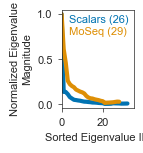

In [32]:
figsize_cm=(4, 4)
figsize = [x/2.54 for x in figsize_cm]

scalar_cov = pca_scalars_df.cov()
scalar_eig_val, _scalar_eig_vec = np.linalg.eig(scalar_cov)

moseq_cov = pca_moseq_df.cov()
moseq_eig_val, _moseq_eig_vec = np.linalg.eig(moseq_cov)

scalar_eig_val = scalar_eig_val / scalar_eig_val.max()
scalar_effective_dims = (scalar_eig_val >= 0.01).sum()
moseq_eig_val = moseq_eig_val / moseq_eig_val.max()
moseq_effective_dims = (moseq_eig_val >= 0.01).sum()

fig, ax = plt.subplots(figsize=figsize)
ax.plot(scalar_eig_val, lw=3, label=f"Scalars ({scalar_effective_dims})", c=segmenter_cmap_dict["Scalars"])
ax.plot(moseq_eig_val, lw=3, label=f"MoSeq ({moseq_effective_dims})", c=segmenter_cmap_dict["MoSeq"])
ax.set_xlim([0, 35])
handles, labels = ax.get_legend_handles_labels()
text_shift = 0.125
for i, (h, l) in enumerate(zip(handles, labels)):
    ax.text(0.1, 0.95-i*text_shift, l, c=h.get_color(), ha="left", va="top", transform=ax.transAxes)
ax.set_xlabel("Sorted Eigenvalue ID")
ax.set_ylabel("Normalized Eigenvalue\nMagnitude")
fig.tight_layout()
fig.subplots_adjust(right=0.9)
fig.savefig(plot_output_dir / "Fig4PanelE.svg", dpi=default_dpi)

## Panel F

In [33]:
plot_df = pd.concat({"Scalars": approach_scalars_cosine_distances_df.loc["pca"].groupby(["drug_class1", "drug1", "dose1", "mouse_names1", "within_or_between"], sort=False).mean(),
           "MoSeq": approach_moseq_cosine_distances_df.loc["pca"].groupby(["drug_class1", "drug1", "dose1", "mouse_names1", "within_or_between"], sort=False).mean()}, names=["model"])

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\1443693548.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fg.axes.flatten()[-1].set_xticklabels([_drug_to_abbr(x.get_text()) for x in fg.axes.flatten()[-1].get_xticklabels()])


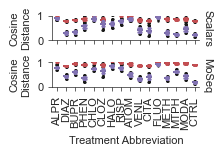

In [34]:
figsize_cm=(6, 4)
figsize = [x/2.54 for x in figsize_cm]

fg = sns.FacetGrid(plot_df.reset_index(), row="model", row_order=["Scalars", "MoSeq"], margin_titles=True, height=2, aspect=1.7)

fg.map_dataframe(sns.pointplot, x="drug1", y="cosine_distance", hue="within_or_between", palette=["k", "k"], dodge=False, errorbar="sd", ls="none", capsize=0.1, markers="_", zorder=0, legend=False)
fg.map_dataframe(sns.pointplot, x="drug1", y="cosine_distance", hue="within_or_between", palette=["r", "m"], dodge=False, errorbar="ci", ls="none", capsize=0.25, markers="_", zorder=1)
fg.set(ylim=[0, 1], xlabel="")
fg.axes.flatten()[-1].tick_params("x", rotation=90)
fg.axes.flatten()[-1].set_xticklabels([_drug_to_abbr(x.get_text()) for x in fg.axes.flatten()[-1].get_xticklabels()])
fg.set_titles(row_template="{row_name}")
fg.set_ylabels("Cosine\nDistance")
fg.set_xlabels("Treatment Abbreviation")

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.savefig(plot_output_dir / "Fig4PanelF.svg", dpi=default_dpi)

## Panel G

In [35]:
segmenter_rename_dict = {
    "raw_scalars": "Scalars (Original)",
    "raw_moseq": "MoSeq",
    "density_scalars": "Scalars (Density)"
}

extended_app_seg_c_global_recall_series = load_object(data_output_dir / "app_seg_c_global_recall_series.pkl").loc[["raw", "density"]].drop(("density", "moseq"))
_idx = extended_app_seg_c_global_recall_series.index.to_frame()
_idx["segmenter"] = _idx["approach"] + "_" + _idx["segmenter"]
extended_app_seg_c_global_recall_series.index = pd.MultiIndex.from_frame(_idx[["segmenter", "C"]])
extended_optimal_c_series = extended_app_seg_c_global_recall_series.groupby("segmenter").apply(lambda x: x.droplevel("segmenter").idxmax())
segmenter_cmap2 = sns.color_palette("colorblind", n_colors=len(segmenter_rename_dict.keys()))
segmenter_cmap_dict2 = {k: segmenter_cmap2[i] for i, k in enumerate(segmenter_rename_dict.keys())}
extended_optimal_c_series

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\825857799.py:7: PerformanceWarning: indexing past lexsort depth may impact performance.
  extended_app_seg_c_global_recall_series = load_object(data_output_dir / "app_seg_c_global_recall_series.pkl").loc[["raw", "density"]].drop(("density", "moseq"))


segmenter
density_scalars    1.000000e+02
raw_moseq          1.000000e+03
raw_scalars        1.000000e-07
Name: global_recall, dtype: float64

C:\Users\marti\AppData\Local\Temp\ipykernel_61228\4014153320.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([r], [c], c=h.get_color(), marker="_", s=50)
C:\Users\marti\AppData\Local\Temp\ipykernel_61228\4014153320.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate("     Optimal\nRegularization", xy=[r, c], xytext=[0.95, 10e-13], va="bottom", ha="left", rotation=90, arrowprops=dict(facecolor='black', arrowstyle="->", color="k", relpos=(1, 0.4), shrinkB=3))


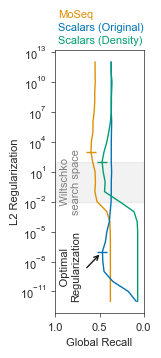

In [36]:
figsize_cm=(4, 9)
figsize = [x/2.54 for x in figsize_cm]

fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(extended_app_seg_c_global_recall_series.sort_index().reset_index(), x="global_recall", y="C", hue="segmenter", hue_order=["raw_moseq", "raw_scalars", "density_scalars"], palette=segmenter_cmap_dict2, ax=ax, orient="y")

handles, labels = ax.get_legend_handles_labels()
text_shift = 0.05
for i, (h, l) in enumerate(zip(handles[::-1], labels[::-1])):
    c = extended_optimal_c_series.loc[l]
    r = extended_app_seg_c_global_recall_series.loc[l, c]
    ax.scatter([r], [c], c=h.get_color(), marker="_", s=50)

    if l == "raw_scalars":
        ax.annotate("     Optimal\nRegularization", xy=[r, c], xytext=[0.95, 10e-13], va="bottom", ha="left", rotation=90, arrowprops=dict(facecolor='black', arrowstyle="->", color="k", relpos=(1, 0.4), shrinkB=3))

    ax.text(0.025, 1.015+i*text_shift, segmenter_rename_dict[l], c=h.get_color(), ha="left", va="bottom", transform=ax.transAxes)
ax.get_legend().remove()

ax.axhspan(ymin=0.01, ymax=100.0, color="grey", alpha=0.1)
ax.text(0.95, 1, "   Wiltschko\nsearch space", ha="left", va="center", c="grey", rotation=90)

ax.set_xlim([1, 0])
ax.set_yscale("log")
ax.set_xlabel("Global Recall")
ax.set_ylabel("L2 Regularization", labelpad=0)

fig.tight_layout()
fig.subplots_adjust(top=0.875, right=0.925)
fig.savefig(plot_output_dir / "Fig4PanelG.svg", dpi=default_dpi)

## Panel H

In [37]:
expected_drug_label_series = vector_df_to_expected_label_series(cross_val_prediction_series).apply(lambda x: x[0]).sort_index()
predicted_drug_label_series = cross_val_prediction_series.apply(lambda x: x[0]).sort_index()

f1_series = predicted_drug_label_series.groupby(["approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: f1_score(x, expected_drug_label_series.loc[x.name], average="weighted")).rename("f1_weighted")
recall_series = predicted_drug_label_series.groupby(["approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: x.eq(expected_drug_label_series.loc[x.name]).value_counts(normalize=True)[True]).rename("global_recall")
f1_series

approach      classifier                    cross_validation  segmenter  phase   
density       Decision Tree                 LOO               MoSeq      Solitary    0.522197
                                                              Scalars    Solitary    0.421601
              K-Nearest Neighbors           LOO               MoSeq      Solitary    0.618038
                                                              Scalars    Solitary    0.479148
              Linear Discriminant Analysis  LOO               MoSeq      Solitary    0.686480
                                                                                       ...   
rescaled_pca  Random Forest                 LOO               Scalars    Solitary    0.511467
              Ridge                         LOO               MoSeq      Solitary    0.605288
                                                              Scalars    Solitary    0.480505
              Support Vector                LOO               MoSeq     

In [38]:
approach_order = ["raw", "density", "pca", "rescaled_pca"]
segmenter_order2 = ["Scalars", "MoSeq"]
selected_classifiers = ["Logistic Regression", "Support Vector", "Linear Discriminant Analysis"]

recall_binom_df = predicted_drug_label_series.groupby(["approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: get_recall_binom_test_series(x.values, expected_drug_label_series.loc[x.name].values, chance_level=1/len(drug_order))).unstack()
treatment_recall_series = predicted_drug_label_series.eq(expected_drug_label_series).groupby(["approach", "classifier", "cross_validation", "segmenter", "phase", "treatment"]).value_counts(normalize=True).unstack().fillna(0)[True].rename("treatment_recall")

classifier_order = list((recall_binom_df.loc["raw"].xs("MoSeq", level="segmenter") - recall_binom_df.loc["raw"].xs("Scalars", level="segmenter"))["recall"].sort_values().index.get_level_values("classifier"))
plot_df = recall_binom_df.loc[pd.IndexSlice[:, :, :, ["Scalars", "MoSeq"]]].reset_index()
plot_df2 = treatment_recall_series.loc[pd.IndexSlice[:, :, :, ["Scalars", "MoSeq"]]].rename("recall").sort_index().reset_index(["approach", "segmenter"])

normalization_order = ["raw_values", "normalized"]
plot_df["x"] = plot_df.apply(lambda x: approach_order.index(x["approach"]), axis=1)
plot_df["x_shift"] = (plot_df.apply(lambda x: segmenter_order2.index(x["segmenter"]), axis=1) - len(segmenter_order2)/2 + 0.5) / len(segmenter_order2) * 0.5
plot_df["x"] += plot_df["x_shift"]
plot_df[["ci_down", "ci_up"]] = (plot_df[["low", "high"]].T - plot_df["recall"]).T.abs()

plot_df2["x"] = plot_df2.apply(lambda x: approach_order.index(x["approach"]), axis=1)
plot_df2["x_shift"] = (plot_df2.apply(lambda x: segmenter_order2.index(x["segmenter"]), axis=1) - len(segmenter_order2)/2 + 0.5) / len(segmenter_order2) * 0.5
plot_df2["x"] += plot_df2["x_shift"]
plot_df2 = plot_df2.set_index("segmenter", append=True)

norm_cmap = sns.color_palette("colorblind", n_colors=len(normalization_order))
norm_cmap_dict = {k: norm_cmap[i] for i, k in enumerate(normalization_order)}

segmenter_cmap = sns.color_palette("colorblind", n_colors=len(segmenter_order2))
segmenter_cmap_dict = {k: segmenter_cmap[i] for i, k in enumerate(segmenter_order2)}

significance_df = apply_statistical_test_to_series(treatment_recall_series.loc[pd.IndexSlice[:, :, :, ["Scalars", "MoSeq"]]].droplevel("phase"), comparison_levels=["segmenter"], group_levels=["approach", "classifier", "cross_validation"], pair_levels=["treatment"], parametric_test=False)
significance_threshold = 0.05 / 40# recall_binom_df.index.get_level_values("classifier").nunique()
significance_df["phase_significance"] = significance_df["pvalue"].lt(significance_threshold)
significance_df = significance_df.join(plot_df.groupby(["approach", "classifier", "cross_validation"])[["x", "recall"]].mean())
significance_df

statistic  \
approach     classifier                   cross_validation comparison1 comparison2              
density      Decision Tree                LOO              MoSeq       Scalars            7.0   
             K-Nearest Neighbors          LOO              MoSeq       Scalars            4.0   
             Linear Discriminant Analysis LOO              MoSeq       Scalars            5.0   
             Logistic Regression          LOO              MoSeq       Scalars           14.0   
             Naive Bayes                  LOO              MoSeq       Scalars           10.0   
             Nearest Centroid             LOO              MoSeq       Scalars            9.0   
             Perceptron                   LOO              MoSeq       Scalars           56.5   
             Random Forest                LOO              MoSeq       Scalars           11.5   
             Ridge                        LOO              MoSeq       Scalars           30.0   
             Support Vector               LOO              MoSeq       Scalars            1.0   
pca          Decision Tree                LOO              MoSeq       Scalars           20.0   
             K-Nearest Neighbors          LOO              MoSeq       Scalars            8.0   
             Linear Discriminant Analysis LOO              MoSeq       Scalars           11.0   
             Logistic Regression          LOO              MoSeq       Scalars           15.0   
             Naive Bayes                  LOO              MoSeq       Scalars            5.0   
             Nearest Centroid             LOO              MoSeq       Scalars           29.0   
             Perceptron                   LOO              MoSeq       Scalars           33.0   
             Random Forest                LOO              MoSeq       Scalars            1.0   
             Ridge                        LOO              MoSeq       Scalars           33.0   
             Support Vector               LOO              MoSeq       Scalars           21.0   
raw          Decision Tree                LOO              MoSeq       Scalars           15.0   
             K-Nearest Neighbors          LOO              MoSeq       Scalars            8.0   
             Linear Discriminant Analysis LOO              MoSeq       Scalars            3.0   
             Logistic Regression          LOO              MoSeq       Scalars            3.0   
             Naive Bayes                  LOO              MoSeq       Scalars           10.0   
             Nearest Centroid             LOO              MoSeq       Scalars           10.0   
             Perceptron                   LOO              MoSeq       Scalars           21.0   
             Random Forest                LOO              MoSeq       Scalars            7.5   
             Ridge                        LOO              MoSeq       Scalars           22.0   
             Support Vector               LOO              MoSeq       Scalars            3.0   
rescaled_pca Decision Tree                LOO              MoSeq       Scalars           13.5   
             K-Nearest Neighbors          LOO              MoSeq       Scalars            0.0   
             Linear Discriminant Analysis LOO              MoSeq       Scalars            6.0   
             Logistic Regression          LOO              MoSeq       Scalars           14.0   
             Naive Bayes                  LOO              MoSeq       Scalars            0.0   
             Nearest Centroid             LOO              MoSeq       Scalars            9.5   
             Perceptron                   LOO              MoSeq       Scalars            7.0   
             Random Forest                LOO              MoSeq       Scalars            7.0   
             Ridge                        LOO              MoSeq       Scalars           10.0   
             Support Vector               LOO              MoSeq       Scalars            4.0   

         

In [39]:
lm = ols(formula="treatment_recall ~ C(classifier) * C(segmenter)", data=treatment_recall_series.loc["raw"].reset_index()).fit()
table = sm.stats.anova_lm(lm, typ=2) # Type 2 ANOVA DataFrame
table["significant"] = table["PR(>F)"].lt(0.05 / len(table))
table

,sum_sq,df,F,PR(>F),significant
C(classifier),2.754666,9.0,7.216318,1.700856e-09,True
C(segmenter),1.016367,1.0,23.962927,1.606722e-06,True
C(classifier):C(segmenter),0.585901,9.0,1.534868,1.348779e-01,False
Residual,12.724247,300.0,NaN,NaN,False


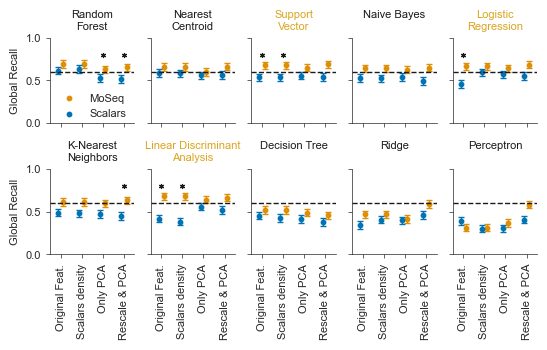

In [40]:
figsize_cm=(14, 9)
figsize = [x/2.54 for x in figsize_cm]

ticklabel_rename_dict = {
    "raw": "Original Feat.",
    "density": "Scalars density",
    "pca": "Only PCA",
    "rescaled_pca": "Rescale & PCA"
}

fg = sns.FacetGrid(plot_df.reset_index(), col="classifier", col_order=recall_binom_df.loc["raw"].groupby("classifier")["recall"].mean().sort_values(ascending=False).index, col_wrap=5, margin_titles=True)

def _plot(data, *args, **kwargs):
    ax = plt.gca()

    approach = data["approach"].unique()[0]
    classifier = data["classifier"].unique()[0]
    cross_validation = data["cross_validation"].unique()[0]
    full_data = data.copy()

    for segmenter, data in full_data.groupby("segmenter"):
        data2 = plot_df2.loc[classifier, cross_validation,:, :, segmenter]

        ax.scatter(data["x"], data["recall"], s=10, color=segmenter_cmap_dict[segmenter], label=segmenter if classifier=="Random Forest" else None)
        ax.errorbar(data["x"], data["recall"], yerr=(data["ci_down"], data["ci_up"]), ls="none", capsize=2, color=segmenter_cmap_dict[segmenter])

        # ax.scatter(data2["x"], data2["recall"], s=10, color=segmenter_cmap_dict[segmenter], alpha=0.1)

        _plot_significance_df = significance_df.loc[:, classifier, cross_validation]
        _plot_significance_df = _plot_significance_df[_plot_significance_df["phase_significance"]]
        x, y = _plot_significance_df["x"], _plot_significance_df["recall"]
        ax.scatter(x=x, y=y-y+0.8, marker="$*$", s=10, c="k", linewidth=0.5)

fg.map_dataframe(_plot)
fg.tick_params("x", rotation=90)
fg.set_titles(row_template="{row_name}", col_template="{col_name}")
# fg.add_legend()
fg.set(ylim=[0,1], xlim=[-0.5, 3.5], xticks=[0, 1, 2, 3])
fg.refline(y=0.6, ls="--", c="k")
fg.set_ylabels("Global Recall")
fg.set_xticklabels(labels=approach_order)

title_rename_dict = {
    "Logistic Regression": "Logistic\nRegression",
    "Support Vector": "Support\nVector",
    "Nearest Centroid": "Nearest\nCentroid",
    "Random Forest": "Random\nForest",
    "K-Nearest Neighbors": "K-Nearest\nNeighbors",
    "Linear Discriminant Analysis": "Linear Discriminant\nAnalysis"
    }

for ax in fg.axes.flatten():
    title_text = ax.get_title()
    new_title = title_rename_dict.get(title_text, title_text + "\n")
    title_color = "goldenrod" if title_text in selected_classifiers else "k"
    ax.set_title(new_title, c=title_color)

fg.axes.flatten()[0].legend(frameon=False, loc="center", bbox_to_anchor=(0.5,0.2,0,0))
fg.set_xticklabels(ticklabel_rename_dict.values())

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.savefig(plot_output_dir / "Fig4PanelH.svg", dpi=default_dpi)

# Figure 5

18 x 12cm

First row

    Panel a: 18 x 6
    Panel b: 18 x 6

## Panel A

In [41]:
classifier_rename_dict = dict(
    NC_Manhattan="Nearest Centroid", 
    DecisionTree="Decision Tree", 
    KNeighbors="K-Nearest Neighbors", 
    LDA="Linear Discriminant Analysis", 
    LogReg_Optimized="Logistic Regression",
    NaiveBayes="Naive Bayes",
    Perceptron="Perceptron",
    RandomForest="Random Forest",
    Ridge="Ridge",
    SVC="Support Vector"
    )

subset_prediction_dict = load_object(data_output_dir / "subset_prediction_dict.pkl")
subset_prediction_series = pd.concat(subset_prediction_dict, names=["drug_subset", "approach", "classifier", "cross_validation"])
_idx_names = subset_prediction_series.index.names
subset_prediction_series = subset_prediction_series.reset_index()
subset_prediction_series["classifier"] = subset_prediction_series["classifier"].apply(classifier_rename_dict.get)
subset_prediction_series["segmenter"] = subset_prediction_series["segmenter"].apply(dict(scalars="Scalars", moseq="MoSeq").get)
subset_prediction_series = subset_prediction_series.set_index(_idx_names)[0]

subset_expected_drug_label_series = vector_df_to_expected_label_series(subset_prediction_series).apply(lambda x: x[0]).sort_index()
subset_predicted_drug_label_series = subset_prediction_series.apply(lambda x: x[0]).sort_index()

f1_series = subset_predicted_drug_label_series.groupby(["drug_subset", "approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: f1_score(x, subset_expected_drug_label_series.loc[x.name], average="weighted")).rename("f1_weighted")
recall_series = subset_predicted_drug_label_series.groupby(["drug_subset", "approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: x.eq(subset_expected_drug_label_series.loc[x.name]).value_counts(normalize=True)[True]).rename("global_recall")
recall_series

drug_subset     approach  classifier           cross_validation  segmenter  phase   
antidepressant  raw       Logistic Regression  LOO               MoSeq      Solitary    0.886364
                                                                 Scalars    Solitary    0.750000
                          Nearest Centroid     LOO               MoSeq      Solitary    0.875000
                                                                 Scalars    Solitary    0.818182
                          Random Forest        LOO               MoSeq      Solitary    0.863636
                                                                 Scalars    Solitary    0.784091
                          Support Vector       LOO               MoSeq      Solitary    0.875000
                                                                 Scalars    Solitary    0.750000
antipsychotic   raw       Logistic Regression  LOO               MoSeq      Solitary    0.816568
                                          

In [42]:
drug_subset_order = list(raw_scalars_df.index.get_level_values("drug_class").unique())

subset_recall_binom_df = subset_predicted_drug_label_series.groupby(["drug_subset", "approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: get_recall_binom_test_series(x.values, subset_expected_drug_label_series.loc[x.name].values, chance_level=1/4)).unstack()
subset_treatment_recall_series = subset_predicted_drug_label_series.eq(subset_expected_drug_label_series).groupby(["drug_subset", "approach", "classifier", "cross_validation", "segmenter", "phase", "treatment"]).value_counts(normalize=True).unstack().fillna(0)[True]

plot_df = subset_recall_binom_df.loc[pd.IndexSlice[:, :, :, :, ["Scalars", "MoSeq"]]].reset_index()
plot_df2 = subset_treatment_recall_series.loc[pd.IndexSlice[:, :, :, :, ["Scalars", "MoSeq"]]].rename("recall").sort_index().reset_index(["drug_subset", "segmenter"])

normalization_order = ["raw_values", "normalized"]
plot_df["x"] = plot_df.apply(lambda x: drug_subset_order.index(x["drug_subset"]), axis=1)
plot_df["x_shift"] = (plot_df.apply(lambda x: segmenter_order2.index(x["segmenter"]), axis=1) - len(segmenter_order2)/2 + 0.5) / len(segmenter_order2) * 0.5
plot_df["x"] += plot_df["x_shift"]
plot_df[["ci_down", "ci_up"]] = (plot_df[["low", "high"]].T - plot_df["recall"]).T.abs()

plot_df2["x"] = plot_df2.apply(lambda x: drug_subset_order.index(x["drug_subset"]), axis=1)
plot_df2["x_shift"] = (plot_df2.apply(lambda x: segmenter_order2.index(x["segmenter"]), axis=1) - len(segmenter_order2)/2 + 0.5) / len(segmenter_order2) * 0.5
plot_df2["x"] += plot_df2["x_shift"]
plot_df2 = plot_df2.set_index("segmenter", append=True)

norm_cmap = sns.color_palette("colorblind", n_colors=len(normalization_order))
norm_cmap_dict = {k: norm_cmap[i] for i, k in enumerate(normalization_order)}

segmenter_cmap = sns.color_palette("colorblind", n_colors=len(segmenter_order2))
segmenter_cmap_dict = {k: segmenter_cmap[i] for i, k in enumerate(segmenter_order2)}

significance_df = apply_statistical_test_to_series(subset_treatment_recall_series.loc[pd.IndexSlice[:, :, :, :, ["Scalars", "MoSeq"]]].droplevel("phase"), comparison_levels=["segmenter"], group_levels=["drug_subset", "approach", "classifier", "cross_validation"], pair_levels=["treatment"], parametric_test=False)
significance_threshold = 0.05 / len(significance_df)
significance_df["phase_significance"] = significance_df["pvalue"].lt(significance_threshold)
significance_df = significance_df.join(plot_df.groupby(["drug_subset", "approach", "classifier", "cross_validation"])[["x", "recall"]].mean())
significance_df

e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
e:\Users\marti\miniconda3\envs\CNS_DR\Lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWa

statistic  \
drug_subset    approach classifier          cross_validation comparison1 comparison2              
antidepressant raw      Logistic Regression LOO              MoSeq       Scalars            0.0   
                        Nearest Centroid    LOO              MoSeq       Scalars            0.0   
                        Random Forest       LOO              MoSeq       Scalars            1.0   
                        Support Vector      LOO              MoSeq       Scalars            0.0   
antipsychotic  raw      Logistic Regression LOO              MoSeq       Scalars            0.0   
                        Nearest Centroid    LOO              MoSeq       Scalars            0.0   
                        Random Forest       LOO              MoSeq       Scalars            2.0   
                        Support Vector      LOO              MoSeq       Scalars            2.0   
benzo          raw      Logistic Regression LOO              MoSeq       Scalars            0.0   
                        Nearest Centroid    LOO              MoSeq       Scalars            0.0   
                        Random Forest       LOO              MoSeq       Scalars            0.0   
                        Support Vector      LOO              MoSeq       Scalars            1.0   
snri           raw      Logistic Regression LOO              MoSeq       Scalars            0.0   
                        Nearest Centroid    LOO              MoSeq       Scalars            0.0   
                        Random Forest       LOO              MoSeq       Scalars            0.0   
                        Support Vector      LOO              MoSeq       Scalars            0.0   
ssri           raw      Logistic Regression LOO              MoSeq       Scalars            1.0   
                        Nearest Centroid    LOO              MoSeq       Scalars            3.0   
                        Support Vector      LOO              MoSeq       Scalars            0.0   
stimulant      raw      Logistic Regression LOO              MoSeq       Scalars            3.0   
                        Nearest Centroid    LOO              MoSeq       Scalars            0.0   
                        Support Vector      LOO              MoSeq       Scalars            0.0   

                                                                                        pvalue  \
drug_subset    approach classifier          cross_validation comparison1 comparison2             
antidepressant raw      Logistic Regression LOO              MoSeq       Scalars      0.250000   
                        Nearest Centroid    LOO              MoSeq       Scalars      0.179712   
                        Random Forest       LOO              MoSeq       Scalars      0.500000   
                        Support Vector      LOO              MoSeq       Scalars      0.250000   
antipsychotic  raw      Logistic Regression LOO              MoSeq       Scalars      0.067889   
                        Nearest Centroid    LOO              MoSeq       Scalars      0.062500   
                        Random Forest       LOO              MoSeq       Scalars      0.187500   
                        Support Vector      LOO              MoSeq       Scalars      0.187500   
benzo          raw      Logistic Regression LOO              MoSeq       Scalars      0.250000   
                        Nearest Centroid    LOO              MoSeq       Scalars      0.250000   
                        Random Forest       LOO              MoSeq       Scalars      0.250000   
                        Support Vector      LOO              MoSeq       Scalars      0.500000   
snri           raw      Logistic Regression LOO              MoSeq       Scalars      0.250000   
                        Nearest Centroid    LOO              MoSeq       Scalars      0.250000   
                        Random Forest       LOO              MoSeq       Scalars      0.250000   
                        Support Vector     

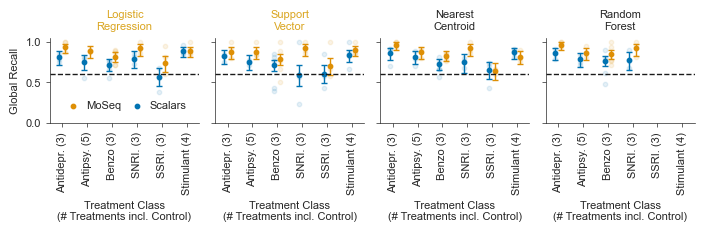

In [43]:
figsize_cm=(18, 6)
figsize = [x/2.54 for x in figsize_cm]

fg = sns.FacetGrid(plot_df.set_index("approach").loc["raw"].reset_index(), col="classifier", col_order=["Logistic Regression", "Support Vector", "Nearest Centroid", "Random Forest"], margin_titles=True)
selected_classifiers = ["Logistic Regression", "Support Vector", "Linear Discriminant Analysis"]
ticklabel_rename_dict = {
    "antidepressant": "Antidepr.",
    "antipsychotic": "Antipsy.",
    "benzo": "Benzo",
    "snri": "SNRI.",
    "ssri": "SSRI.",
    "stimulant": "Stimulant",
}
ticklabel_rename_dict = {k: v + f" ({raw_scalars_df.index.to_frame(index=False).groupby('drug_class')['drug'].nunique().loc[k]+1})" for k,v in ticklabel_rename_dict.items()}


def _plot(data, *args, **kwargs):
    ax = plt.gca()

    drug_subset = data["drug_subset"].unique()[0]
    approach = data["approach"].unique()[0]
    classifier = data["classifier"].unique()[0]
    cross_validation = data["cross_validation"].unique()[0]
    full_data = data.copy()

    for segmenter, data in full_data.groupby("segmenter"):
        data2 = plot_df2.loc[approach, classifier, cross_validation,:, :, segmenter]

        ax.scatter(data["x"], data["recall"], s=10, color=segmenter_cmap_dict[segmenter], label=segmenter)
        ax.errorbar(data["x"], data["recall"], yerr=(data["ci_down"], data["ci_up"]), ls="none", capsize=2, color=segmenter_cmap_dict[segmenter])

        ax.scatter(data2["x"], data2["recall"], s=10, color=segmenter_cmap_dict[segmenter], alpha=0.1)

        _plot_significance_df = significance_df.loc[:, approach, classifier, cross_validation]
        _plot_significance_df = _plot_significance_df[_plot_significance_df["phase_significance"]]
        x, y = _plot_significance_df["x"], _plot_significance_df["recall"]
        # ax.scatter(x=x, y=y-y+0.8, marker="$*$", s=10, c="k")


fg.map_dataframe(_plot)
fg.tick_params("x", rotation=90)
fg.set_titles(row_template="{row_name}", col_template="{col_name}")
fg.set(ylim=[0,1.05], xlim=[-0.5, 5.5], xticks=list(range(len(drug_subset_order)-1)))
fg.refline(y=0.6, ls="--", c="k")
fg.set_ylabels("Global Recall")

title_rename_dict = {
    "Logistic Regression": "Logistic\nRegression",
    "Support Vector": "Support\nVector",
    "Nearest Centroid": "Nearest\nCentroid",
    "Random Forest": "Random\nForest"
    }

for ax in fg.axes.flatten():
    title_text = ax.get_title()
    new_title = title_rename_dict.get(title_text, title_text)
    if  title_text in selected_classifiers:
        ax.set_title(new_title, c="goldenrod")
    else:
        ax.set_title(new_title)

fg.axes.flatten()[0].legend(frameon=False, loc="center", bbox_to_anchor=(0.5,0.2,0,0), ncols=2, columnspacing=0.5, handletextpad=0.1)

fg.set_xticklabels(ticklabel_rename_dict.values())
fg.set_xlabels("Treatment Class\n(# Treatments incl. Control)")

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.savefig(plot_output_dir / "Fig5PanelA.svg", dpi=default_dpi)


## Panel B

In [44]:
full_subset_prediction_dict = load_object(data_output_dir / "full_subset_prediction_dict.pkl")        
len(full_subset_prediction_dict)

51

In [45]:
classifier_rename_dict = dict(
    NC_Manhattan="Nearest Centroid", 
    DecisionTree="Decision Tree", 
    KNeighbors="K-Nearest Neighbors", 
    LDA="Linear Discriminant Analysis", 
    LogReg_Optimized="Logistic Regression",
    NaiveBayes="Naive Bayes",
    Perceptron="Perceptron",
    RandomForest="Random Forest",
    Ridge="Ridge",
    SVC="Support Vector"
    )

full_subset_prediction_series = pd.concat(full_subset_prediction_dict, names=["subset_length", "subset_id", "approach", "classifier", "cross_validation"])
_idx = full_subset_prediction_series.index.names
full_subset_prediction_series = full_subset_prediction_series.reset_index()
full_subset_prediction_series["classifier"] = full_subset_prediction_series["classifier"].apply(classifier_rename_dict.get)
full_subset_prediction_series["segmenter"] = full_subset_prediction_series["segmenter"].apply(dict(scalars="Scalars", moseq="MoSeq").get)
full_subset_prediction_series = full_subset_prediction_series.set_index(_idx)[0]
full_subset_prediction_series

subset_length  subset_id  approach  classifier           cross_validation  segmenter  phase     treatment   uniform_dosage_term  treatment_mouse_id
1              0          raw       Logistic Regression  LOO               MoSeq      Solitary  VEH         medium               0                             (VEH, medium)
                                                                                                                                 1                             (VEH, medium)
                                                                                                                                 2                             (VEH, medium)
                                                                                                                                 3                             (VEH, medium)
                                                                                                                                 4                             (

In [46]:
expected_drug_label_series = vector_df_to_expected_label_series(full_subset_prediction_series).apply(lambda x: x[0]).sort_index()
predicted_drug_label_series = full_subset_prediction_series.apply(lambda x: x[0]).sort_index()

f1_series = predicted_drug_label_series.groupby(["subset_length", "subset_id", "approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: f1_score(x, expected_drug_label_series.loc[x.name], average="weighted")).rename("f1_weighted")
recall_series = predicted_drug_label_series.groupby(["subset_length", "subset_id", "approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: x.eq(expected_drug_label_series.loc[x.name]).value_counts(normalize=True)[True]).rename("global_recall")
f1_series

subset_length  subset_id  approach  classifier           cross_validation  segmenter  phase   
1              0          raw       Logistic Regression  LOO               MoSeq      Solitary    0.938017
                                                                           Scalars    Solitary    0.922877
                                    Nearest Centroid     LOO               MoSeq      Solitary    0.969312
                                                                           Scalars    Solitary    0.910516
                                    Support Vector       LOO               MoSeq      Solitary    0.858506
                                                                                                    ...   
               14         raw       Nearest Centroid     LOO               Scalars    Solitary    0.805110
                                    Support Vector       LOO               MoSeq      Solitary    0.975610
                                                 

In [47]:
segmenter_order2 = ["Scalars", "MoSeq"]

recall_binom_df = predicted_drug_label_series.groupby(["subset_length", "subset_id", "approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: get_recall_binom_test_series(x.values, expected_drug_label_series.loc[x.name].values, chance_level=1/len(drug_order))).unstack()
plot_df = recall_binom_df.groupby(["subset_length", "approach", "classifier", "cross_validation", "segmenter", "phase"])[["recall", "low", "high"]].mean().reset_index()
plot_df["x"] = plot_df["subset_length"]
plot_df

,subset_length,approach,classifier,cross_validation,segmenter,phase,recall,low,high,x
0,1,raw,Logistic Regression,LOO,MoSeq,Solitary,0.974770,0.886986,0.992096,1
1,1,raw,Logistic Regression,LOO,Scalars,Solitary,0.877560,0.757202,0.945483,1
2,1,raw,Nearest Centroid,LOO,MoSeq,Solitary,0.961882,0.872468,0.984749,1
3,1,raw,Nearest Centroid,LOO,Scalars,Solitary,0.887259,0.768809,0.954375,1
4,1,raw,Random Forest,LOO,MoSeq,Solitary,0.990783,0.903975,0.997449,1
5,1,raw,Random Forest,LOO,Scalars,Solitary,0.910203,0.794026,0.962229,1
6,1,raw,Support Vector,LOO,MoSeq,Solitary,0.956939,0.863206,0.982798,1
7,1,raw,Support Vector,LOO,Scalars,Solitary,0.752483,0.614268,0.856814,1
8,3,raw,Nearest Centroid,LOO,MoSeq,Solitary,0.885714,0.808874,0.939533,3
9,3,raw,Nearest Centroid,LOO,Scalars,Solitary,0.790476,0.700142,0.863789,3


In [48]:
significance_df = apply_statistical_test_to_series(recall_series.loc[pd.IndexSlice[:, :, :, :, :, ["Scalars", "MoSeq"]]].droplevel("phase"), comparison_levels=["segmenter"], group_levels=["subset_length", "approach", "classifier", "cross_validation"], parametric_test=False)
significance_threshold = 0.05 / (len(significance_df))
significance_df["phase_significance"] = significance_df["pvalue"].lt(significance_threshold)
significance_df = significance_df.join(plot_df.groupby(["subset_length", "approach", "classifier", "cross_validation"])[["x", "recall"]].mean())
significance_df

statistic  \
subset_length approach classifier          cross_validation comparison1 comparison2              
1             raw      Logistic Regression LOO              MoSeq       Scalars          164.0   
                       Nearest Centroid    LOO              MoSeq       Scalars          185.5   
                       Random Forest       LOO              MoSeq       Scalars           40.0   
                       Support Vector      LOO              MoSeq       Scalars          178.5   
3             raw      Nearest Centroid    LOO              MoSeq       Scalars            1.0   

                                                                                       pvalue  \
subset_length approach classifier          cross_validation comparison1 comparison2             
1             raw      Logistic Regression LOO              MoSeq       Scalars      0.002068   
                       Nearest Centroid    LOO              MoSeq       Scalars      0.002297   
                       Random Forest       LOO              MoSeq       Scalars      0.033792   
                       Support Vector      LOO              MoSeq       Scalars      0.000200   
3             raw      Nearest Centroid    LOO              MoSeq       Scalars      1.000000   

                                                                                     phase_significance  \
subset_length approach classifier          cross_validation comparison1 comparison2                       
1             raw      Logistic Regression LOO              MoSeq       Scalars                    True   
                       Nearest Centroid    LOO              MoSeq       Scalars                    True   
                       Random Forest       LOO              MoSeq       Scalars                   False   
                       Support Vector      LOO              MoSeq       Scalars                    True   
3             raw      Nearest Centroid    LOO              MoSeq       Scalars                   False   

                                                                                       x  \
subset_length approach classifier          cross_validation comparison1 comparison2        
1             raw      Logistic Regression LOO              MoSeq       Scalars      1.0   
                       Nearest Centroid    LOO              MoSeq       Scalars      1.0   
                       Random Forest       LOO              MoSeq       Scalars      1.0   
                       Support Vector      LOO              MoSeq       Scalars      1.0   
3             raw      Nearest Centroid    LOO              MoSeq       Scalars      3.0   

                                                                                       recall  
subset_length approach classifier          cross_validation comparison1 comparison2            
1             raw      Logistic Regression LOO              MoSeq       Scalars      0.926165  
                       Nearest Centroid    LOO              MoSeq       Scalars      0.924570  
                       Random Forest       LOO              MoSeq       Scalars      0.950493  
                       Support Vector      LOO              MoSeq       Scalars      0.854711  
3             raw      Nearest Centroid    LOO              MoSeq       Scalars      0.838095

ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (8).

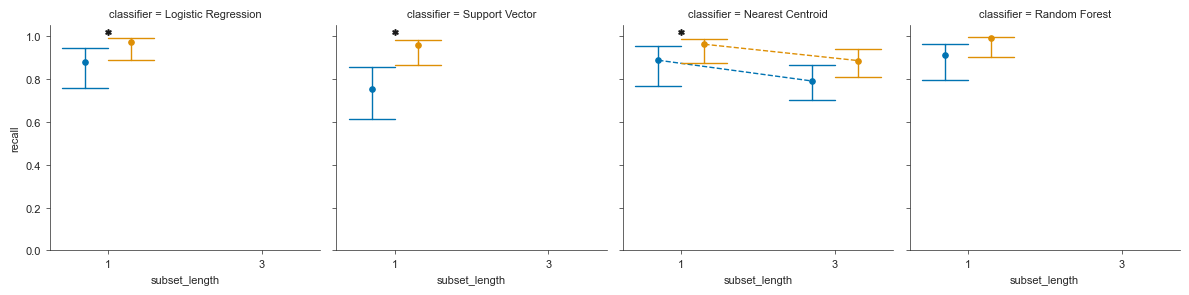

In [49]:
figsize_cm=(18, 6)
figsize = [x/2.54 for x in figsize_cm]

_plot_df = pd.concat([plot_df, plot_df], axis=0)

def _test_errorbar(input_vector):
    return tuple(_plot_df.head(int(len(_plot_df)/2)).loc[input_vector.index[0], ["low", "high"]].values)

def _plot(data, **kwargs):
    ax = plt.gca()

    approach = data["approach"].unique()[0]
    classifier = data["classifier"].unique()[0]
    cross_validation = data["cross_validation"].unique()[0]

    _plot_significance_df = significance_df.loc[:, approach, classifier, cross_validation]
    _plot_significance_df = _plot_significance_df[_plot_significance_df["phase_significance"]]
    x, y = _plot_significance_df["x"], _plot_significance_df["recall"]
    x_translation_dict = {int(l.get_text()): l.get_position()[0] for l in ax.get_xticklabels()}
    ax.scatter(x=x.apply(x_translation_dict.get), y=y-y+1.02, marker="$*$", s=15, c="k")
    if 13 in _plot_significance_df.index:
        ax.scatter(x=x_translation_dict[15], y=1.02, marker=r"$*$", s=15, c="k", alpha=0.25)


fg = sns.FacetGrid(_plot_df, col="classifier", col_order=["Logistic Regression", "Support Vector", "Nearest Centroid", "Random Forest"])
fg.map_dataframe(sns.pointplot, x="subset_length", y="recall", hue="segmenter", hue_order=segmenter_order2, palette=segmenter_cmap_dict, errorbar=_test_errorbar, capsize=0.3, dodge=0.3, ls="--", lw=1, ms=4)
fg.map_dataframe(_plot)
fg.set(ylim=[0, 1.05])
fg.set_xticklabels([2, 4, 6, 8, 10, 12, 14, 16])
fg.set_titles(col_template="{col_name}")

fg.set_xlabels("# Sampled Treatments\n(incl. Control)")
fg.set_ylabels("Average Global Recall")
fg.refline(y=0.6, ls="--", c="k")

for ax in fg.axes.flatten():
    title_text = ax.get_title()
    if  title_text in selected_classifiers:
        ax.set_title(title_text, c="goldenrod")

fg.axes.flatten()[0].legend(frameon=False, loc="center", bbox_to_anchor=(0.5,0.2,0,0), ncols=2, columnspacing=0.75, handletextpad=0.2)

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.savefig(plot_output_dir / "Fig5PanelB.svg", dpi=default_dpi)
